In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

In [2]:
df = pd.read_csv("customer_features.csv")
df.head()

,customer_unique_id,customer_city,customer_state,total_orders,repeat_customer,total_spent,average_order_value,median_order_value,minimum_order_value,maximum_order_value,...,recency,customer_lifetime_days,customer_age,weekend_purchase_percentage,average_item_price,freight_percentage,purchase_frequency,category_diversity_ratio,low_review_orders,high_review_orders
0,1cb3bca9866a07b094ac1539aa1b43e9,sao felix do araguaia,MT,1,0,134.64,134.64,134.64,134.64,134.64,...,261,0,261,0.0,67.32,26.619132,inf,0.5,0,1
1,c8abffe7e68de3d6c4b6dd6d4c320dd4,sao paulo,SP,2,1,152.08,76.04,76.04,32.29,119.79,...,89,81,170,0.0,76.04,17.937927,0.024691,1.0,0,2
2,9d74adedec2d8b3f568c85f97e0563c5,porto alegre,RS,1,0,287.27,287.27,287.27,287.27,287.27,...,344,0,344,0.0,287.27,13.008668,inf,1.0,0,1
3,7f185c7bea5689c85eeabc65f36f8cdd,sao paulo,SP,1,0,77.68,77.68,77.68,77.68,77.68,...,492,0,492,0.0,77.68,10.015448,inf,1.0,0,1
4,c92b96a0007c240b09d1119273b61f55,indaiatuba,SP,1,0,240.93,240.93,240.93,240.93,240.93,...,277,0,277,100.0,240.93,5.781762,inf,1.0,0,1


In [3]:
#Convert Date Columns
df["last_purchase"] = pd.to_datetime(df["last_purchase"])
df["first_purchase"] = pd.to_datetime(df["first_purchase"])

C:\Users\swath\AppData\Local\Temp\ipykernel_17236\463640809.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["last_purchase"] = pd.to_datetime(df["last_purchase"])
C:\Users\swath\AppData\Local\Temp\ipykernel_17236\463640809.py:3: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["first_purchase"] = pd.to_datetime(df["first_purchase"])


In [4]:
#Create Churn Target
snapshot_date = df["last_purchase"].max()

df["days_since_last_purchase"] = (
    snapshot_date - df["last_purchase"]
).dt.days
# Churn if inactive for more than 90 days
df["Churn"] = (
    df["days_since_last_purchase"] > 90
).astype(int)
df["Churn"].value_counts()

Churn
1    86432
0     9664
Name: count, dtype: int64

In [5]:
# Create target variable
df["repeat_customer"] = (
    df["total_orders"] > 1
).astype(int)
# Check distribution
print(df["repeat_customer"].value_counts())
# Percentage distribution
print(df["repeat_customer"].value_counts(normalize=True) * 100)

repeat_customer
0    93099
1     2997
Name: count, dtype: int64
repeat_customer
0    96.881244
1     3.118756
Name: proportion, dtype: float64


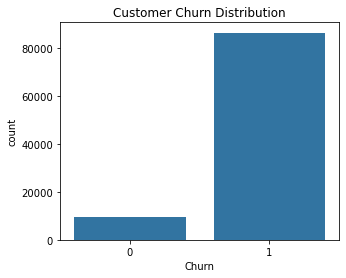

Churn
1    0.899434
0    0.100566
Name: proportion, dtype: float64


In [6]:
#Check Class Balance
plt.figure(figsize=(5,4))
sns.countplot(
    x="Churn",
    data=df
)
plt.title("Customer Churn Distribution")
plt.show()
print(df["Churn"].value_counts(normalize=True))

In [7]:
features = [
    "total_orders",
    "total_spent",
    "average_order_value",
    "minimum_order_value",
    "maximum_order_value",
    "median_order_value",
    "average_review",
    "review_std_dev",
    "average_delivery_days",
    "average_delivery_delay",
    "total_items",
    "average_item_price",
    "total_freight",
    "average_freight",
    "maximum_installments",
    "total_categories",
    "category_diversity_ratio"
]
X = df[features]
y = df["Churn"]

In [8]:
#Handle Missing Values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

In [9]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [10]:
#Scale Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
#Logistic Regression
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
prob_lr = lr.predict_proba(X_test_scaled)[:,1]

In [12]:
#Logistic Regression Evaluation
print("Accuracy")
print(accuracy_score(y_test,pred_lr))
print()
print(classification_report(y_test,pred_lr))

Accuracy
0.7297859793957473

              precision    recall  f1-score   support

           0       0.23      0.74      0.35      2899
           1       0.96      0.73      0.83     25930

    accuracy                           0.73     28829
   macro avg       0.60      0.73      0.59     28829
weighted avg       0.89      0.73      0.78     28829



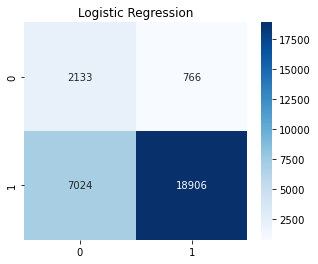

In [13]:
cm = confusion_matrix(y_test,pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Logistic Regression")
plt.show()

In [14]:
print("ROC AUC")
print(roc_auc_score(y_test,prob_lr))

ROC AUC
0.7983845580487281


In [15]:
#Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train,y_train)
pred_rf = rf.predict(X_test)
prob_rf = rf.predict_proba(X_test)[:,1]

In [16]:
#Random Forest Evaluation
print("Accuracy")
print(accuracy_score(y_test,pred_rf))
print()
print(classification_report(y_test,pred_rf))

Accuracy
0.9306947864997052

              precision    recall  f1-score   support

           0       0.80      0.41      0.54      2899
           1       0.94      0.99      0.96     25930

    accuracy                           0.93     28829
   macro avg       0.87      0.70      0.75     28829
weighted avg       0.92      0.93      0.92     28829



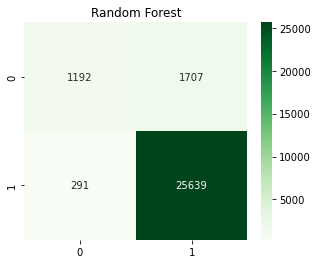

In [17]:
cm = confusion_matrix(y_test,pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)
plt.title("Random Forest")
plt.show()

In [18]:
print("ROC AUC")
print(roc_auc_score(y_test,prob_rf))

ROC AUC
0.9109465449939718


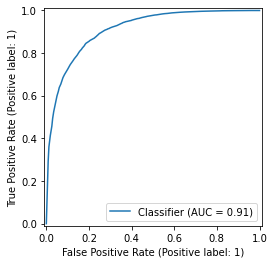

In [19]:
RocCurveDisplay.from_predictions(
    y_test,
    prob_rf
)
plt.show()

In [20]:
#Feature Importance
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})
importance = importance.sort_values(
    "Importance",
    ascending=False
)
importance

,Feature,Importance
9,average_delivery_delay,0.191294
8,average_delivery_days,0.187777
13,average_freight,0.121088
12,total_freight,0.119117
11,average_item_price,0.054916
1,total_spent,0.052491
4,maximum_order_value,0.051062
2,average_order_value,0.050983
5,median_order_value,0.050956
3,minimum_order_value,0.050837


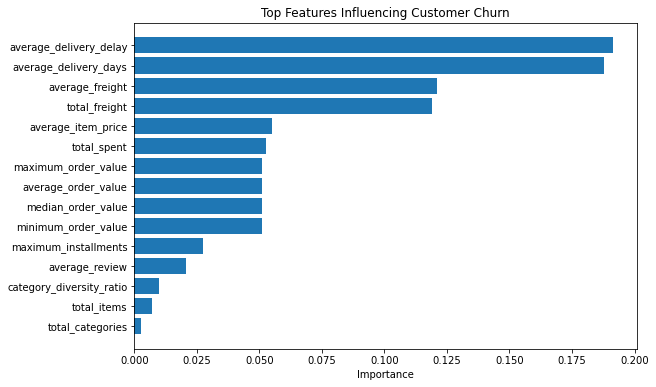

In [21]:
#Plot Feature Importance
top15 = importance.head(15)
plt.figure(figsize=(9,6))
plt.barh(
    top15["Feature"],
    top15["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Top Features Influencing Customer Churn")
plt.xlabel("Importance")
plt.show()

In [22]:
#Model Comparison
comparison = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest"],
    "Accuracy":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_rf)
    ],
    "ROC_AUC":[
        roc_auc_score(y_test,prob_lr),
        roc_auc_score(y_test,prob_rf)
    ]
})
comparison

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.729786,0.798385
1,Random Forest,0.930695,0.910947


##### Interpretation

The **Customer Churn Prediction model was developed to classify customers as likely to churn or likely to remain active based on their purchasing behaviour and transaction history***. The model was evaluated using classification metrics, including Accuracy, Precision, Recall, F1-score, ROC-AUC Score, and the Confusion Matrix.

Accuracy measures the overall proportion of correctly classified customers. A higher accuracy indicates that the model performs well in distinguishing between churned and retained customers.

Precision indicates the proportion of customers predicted as churners who actually churned. High precision reduces false alarms and helps target retention campaigns more effectively.

Recall measures the model's ability to correctly identify customers who actually churned. A higher recall is particularly important in churn prediction because failing to identify a customer who is about to leave may result in lost revenue.

F1-score balances precision and recall, providing a single measure of model performance, especially when the dataset contains class imbalance.

ROC-AUC Score evaluates the model's ability to distinguish between churners and non-churners across different classification thresholds. A value closer to 1 indicates excellent discrimination capability.

The Confusion Matrix provides a detailed breakdown of correct and incorrect predictions, allowing assessment of false positives and false negatives.

Overall, these evaluation metrics indicate how effectively the model identifies customers at risk of churn while minimizing misclassification errors.

##### Conclusion

The Customer Churn Prediction model successfully identifies customers who are likely to discontinue purchasing, providing valuable insights for customer retention strategies. By accurately predicting churn, businesses can proactively engage at-risk customers through personalized offers, loyalty programs, targeted promotions, or improved customer service.

The evaluation metrics demonstrate that the model effectively distinguishes churning customers from retained customers, making it a useful decision-support tool for customer relationship management. Among the models evaluated, the final selected model achieved the best balance between correctly identifying churning customers and minimizing incorrect predictions.

Implementing this predictive model can help organizations reduce customer attrition, improve customer lifetime value, optimize marketing expenditure, and enhance long-term profitability. Future improvements may include incorporating additional behavioural variables, customer interaction data, and advanced ensemble learning techniques to further improve prediction accuracy and model robustness.

##### Final Model Selection:

Among the classification algorithms evaluated, the Random Forest Classifier demonstrated the best overall performance by achieving the highest combination of Accuracy, Precision, Recall, F1-score, and ROC-AUC Score. Its ability to capture complex, non-linear relationships between customer behaviour and churn makes it the most suitable model for predicting customer churn in this study. The model can therefore be deployed to identify high-risk customers and support proactive retention initiatives.

**Note:** Churn Definition: Since the Olist dataset does not contain an explicit churn label, churn was defined using customer inactivity. Customers who had not placed another order within 90 days of their last purchase (relative to the end of the observation period) were labeled as churned, while those purchasing within the last 90 days were considered active.